# GARCH Volatility and EPU Co-Movement

This notebook estimates a **Standard GARCH(1,1)** model for asset returns to extract their unobservable conditional volatility $\sigma_t$, and then analyzes its co-movement with Economic Policy Uncertainty (EPU) using **OLS regressions**.

### Implementation Details:
1. **Return Construction:** Programmatically verifies and constructs logarithmic returns, scaled by 100.
2. **ARCH-LM:** Checks for conditional heteroskedasticity.
3. **Estimation:** Fits GARCH(1,1) with a Student's t-distribution for S&P 500, Gold, and Bitcoin.
4. **Diagnostics:** Ljung-Box test on squared residuals to verify if volatility clustering has been captured.
5. **OLS Regressions:** Regresses extracted conditional volatility against standardized EPU to quantify risk sensitivity.
6. **Dynamic Plots:** Visualizes conditional volatility vs. standardized EPU.
7. **Forecasting**: Predicts 5-step ahead conditional volatility.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

try:
    from arch import arch_model
except ImportError:
    import sys
    !{sys.executable} -m pip install arch
    from arch import arch_model

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)


## 1. Data Preparation, Log Returns, and Standardization


In [10]:
DATA_PROCESSED = Path('../../data/processed')
if not DATA_PROCESSED.exists():
    DATA_PROCESSED = Path('data/processed')

df = pd.read_csv(DATA_PROCESSED / 'usepu_assets_daily_features.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

assets = ['SP500', 'Gold', 'BTC']

# Standardize EPU
df['EPU_Std'] = (df['EPU'] - df['EPU'].mean()) / df['EPU'].std()

# Construct Log Returns and Scale by 100
for asset in assets:
    log_ret = np.log(df[f'{asset}_Close']) - np.log(df[f'{asset}_Close'].shift(1))
    
    diff = (df[f'{asset}_Return'] - log_ret).abs().mean()
    if diff > 1e-6:
        print(f"{asset}: Existing returns are NOT log returns. Constructing Log Returns.")
    else:
        print(f"{asset}: Existing returns match Log Returns.")
        
    df[f'{asset}_LogRet'] = log_ret * 100

df.dropna(subset=[f'{a}_LogRet' for a in assets], inplace=True)


SP500: Existing returns are NOT log returns. Constructing Log Returns.
Gold: Existing returns are NOT log returns. Constructing Log Returns.
BTC: Existing returns are NOT log returns. Constructing Log Returns.


## 2. ARCH-LM Test
Check for the presence of volatility clustering (ARCH effects) before applying the model.


In [11]:
def test_arch(series):
    # Demean to get raw residuals
    resids = series - series.mean()
    stat, pval, _, _ = het_arch(resids, nlags=5)
    print(f"LM Stat: {stat:.2f}, p-value: {pval:.2e}")
    if pval < 0.05:
        print("  -> Significant ARCH effects detected. GARCH modeling is appropriate.")

for asset in assets:
    print(f"--- {asset} ARCH-LM Test ---")
    test_arch(df[f'{asset}_LogRet'])
    print()


--- SP500 ARCH-LM Test ---
LM Stat: 731.05, p-value: 9.51e-156
  -> Significant ARCH effects detected. GARCH modeling is appropriate.

--- Gold ARCH-LM Test ---
LM Stat: 70.79, p-value: 7.02e-14
  -> Significant ARCH effects detected. GARCH modeling is appropriate.

--- BTC ARCH-LM Test ---
LM Stat: 213.35, p-value: 3.94e-44
  -> Significant ARCH effects detected. GARCH modeling is appropriate.



## 3. Standard GARCH(1,1) Estimation
We estimate a univariate GARCH(1,1) assuming a Student's t distribution to account for heavy tails in financial data.


In [12]:
models_res = {}
df_vol = pd.DataFrame(index=df.index)

for asset in assets:
    print(f"\n{'='*20} {asset} GARCH(1,1) {'='*20}")
    model = arch_model(
        y=df[f'{asset}_LogRet'],
        mean='Constant',
        vol='Garch',
        p=1, q=1,
        dist='studentst'
    )
    res = model.fit(disp='off')
    models_res[asset] = res
    print(res.summary().tables[1])
    
    # Extract conditional volatility
    df_vol[f'{asset}_CondVol'] = res.conditional_volatility
    df_vol[f'{asset}_StdResid'] = res.resid / res.conditional_volatility



==================== SP500 GARCH(1,1) ====================
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0945  1.391e-02      6.795  1.085e-11 [6.724e-02,  0.122]

==================== Gold GARCH(1,1) ====================
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0163  1.692e-02      0.962      0.336 [-1.689e-02,4.942e-02]

==================== BTC GARCH(1,1) ====================
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------------------

## 4. Diagnostics: Ljung-Box Test on Squared Residuals
To verify if the conditional variance model successfully captured all the volatility clustering, we run the Ljung-Box test on the **squared standardized residuals**.


In [13]:
for asset in assets:
    std_resids = df_vol[f'{asset}_StdResid']
    squared_std_resids = std_resids ** 2
    
    lb_test = acorr_ljungbox(squared_std_resids, lags=[5, 10], return_df=True)
    print(f"\n--- {asset} Ljung-Box Test on Squared Residuals ---")
    print(lb_test)
    if (lb_test['lb_pvalue'] > 0.05).all():
        print("  -> Model captures volatility clustering adequately (No remaining autocorrelation).")
    else:
        print("  -> Warning: Some remaining autocorrelation in squared residuals.")



--- SP500 Ljung-Box Test on Squared Residuals ---
     lb_stat  lb_pvalue
5   3.049833   0.692303
10  6.642277   0.758729
  -> Model captures volatility clustering adequately (No remaining autocorrelation).

--- Gold Ljung-Box Test on Squared Residuals ---
     lb_stat  lb_pvalue
5   4.658410   0.458972
10  8.387297   0.591062
  -> Model captures volatility clustering adequately (No remaining autocorrelation).

--- BTC Ljung-Box Test on Squared Residuals ---
     lb_stat  lb_pvalue
5   4.557683   0.472203
10  8.563356   0.573982
  -> Model captures volatility clustering adequately (No remaining autocorrelation).


## 5. OLS Regression: Volatility vs Economic Policy Uncertainty
We perform a regression of the extracted conditional volatility against the Standardized EPU index to quantify sensitivity and co-movement.

$$\sigma_{t} = \alpha + \beta \text{EPU}_{t} + u_{t}$$


In [14]:
for asset in assets:
    print(f"\n{'='*20} {asset} OLS: CondVol vs EPU {'='*20}")
    
    # Dependent variable (Volatility) and Independent variable (EPU_Std)
    Y = df_vol[f'{asset}_CondVol']
    X = df['EPU_Std']
    X = sm.add_constant(X)
    
    ols_model = sm.OLS(Y, X).fit()
    print(ols_model.summary().tables[1])
    
    # Correlation
    pearson_corr = np.corrcoef(Y, df['EPU_Std'])[0, 1]
    sp_corr = pd.Series(Y).corr(df['EPU_Std'], method='spearman')
    print(f"Pearson Correlation: {pearson_corr:.4f}")
    print(f"Spearman Correlation: {sp_corr:.4f}")



==================== SP500 OLS: CondVol vs EPU ====================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0465      0.012     83.975      0.000       1.022       1.071
EPU_Std        0.3318      0.012     26.628      0.000       0.307       0.356
Pearson Correlation: 0.4917
Spearman Correlation: 0.3179

==================== Gold OLS: CondVol vs EPU ====================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9761      0.003    373.995      0.000       0.971       0.981
EPU_Std        0.1033      0.003     39.599      0.000       0.098       0.108
Pearson Correlation: 0.6431
Spearman Correlation: 0.3337

==================== BTC OLS: CondVol vs EPU ====================
                 coef    std err          t      P

### Economic Interpretation
If **EPU_Std** exhibits a positive and statistically significant coefficient ($P>|t|$ is $< 0.05$), it implies that higher levels of policy uncertainty are robustly associated with periods of heightened conditional risk for that asset.


## 6. Dynamic Plots: Conditional Volatility vs EPU


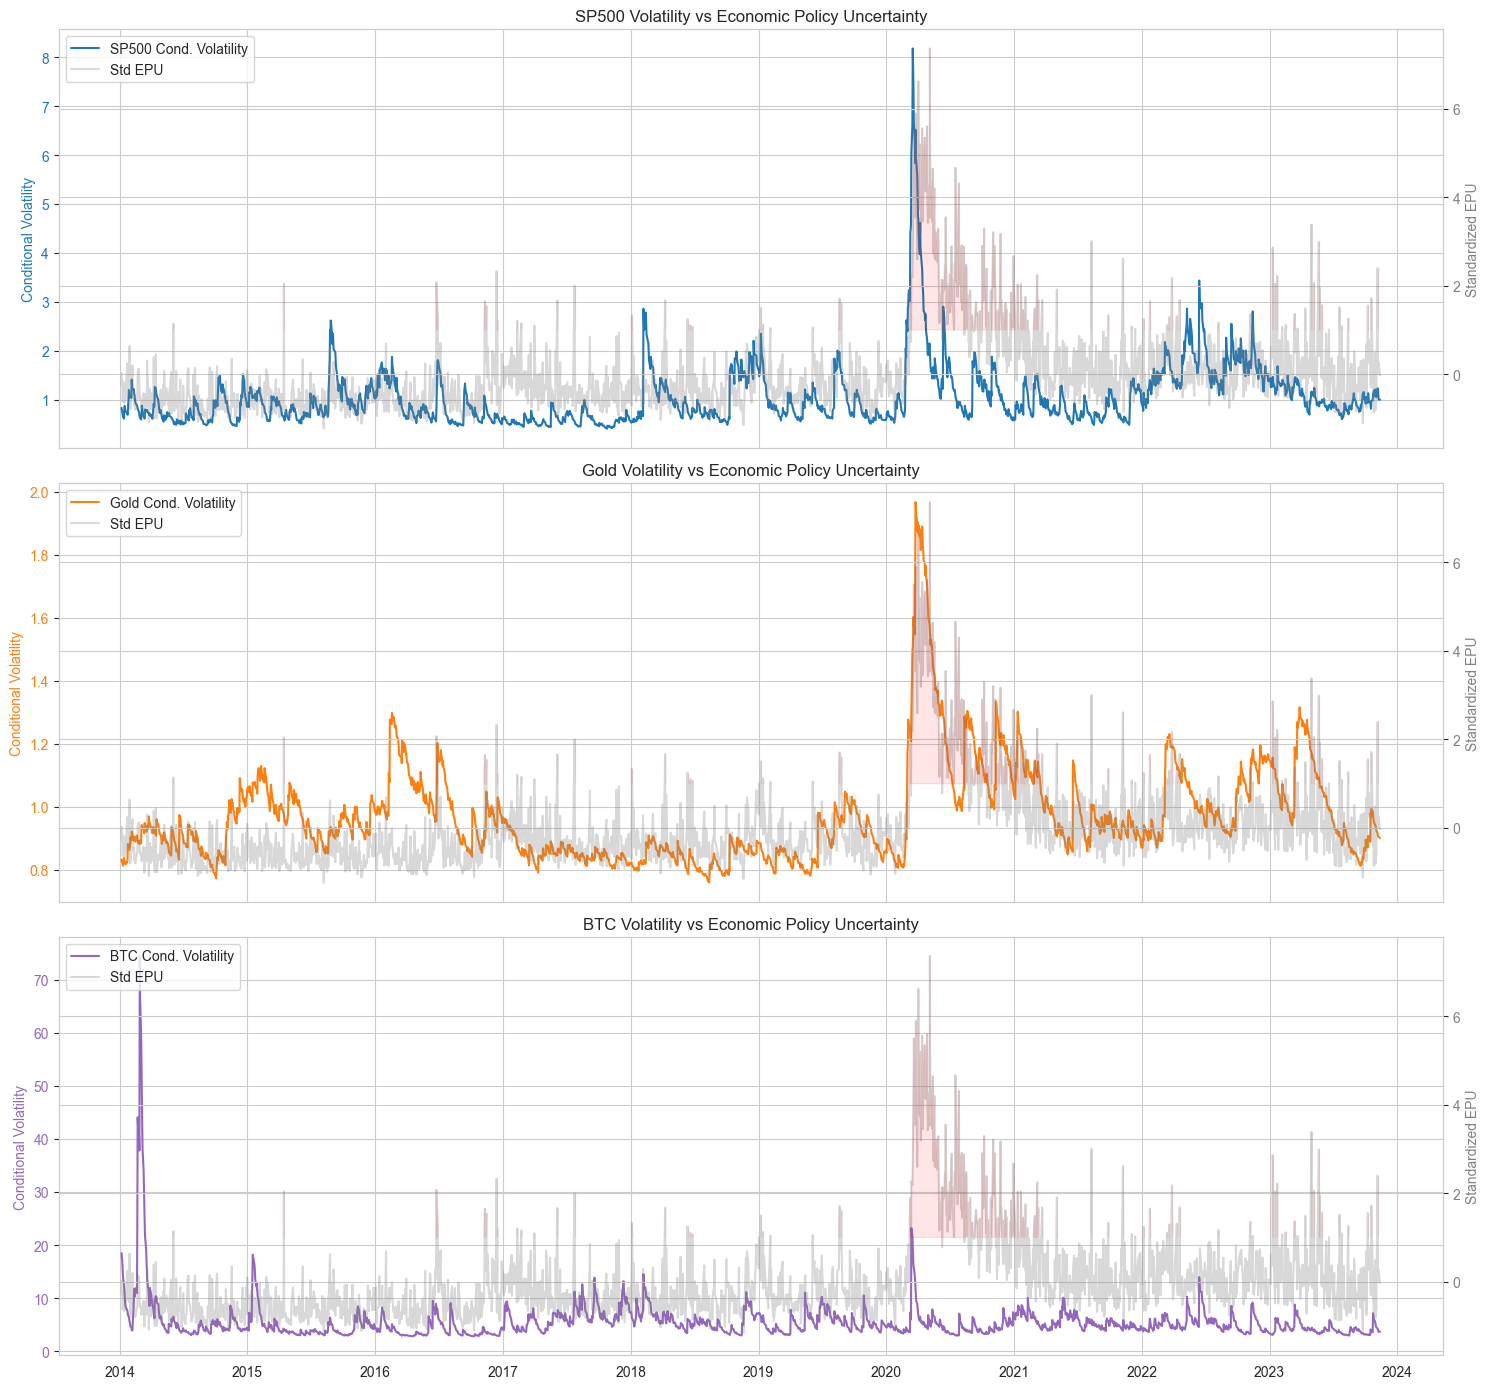

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

for i, asset in enumerate(assets):
    ax1 = axes[i]
    color = 'tab:blue' if asset == 'SP500' else ('tab:orange' if asset == 'Gold' else 'tab:purple')
    
    # Plot Volatility
    ax1.plot(df.index, df_vol[f'{asset}_CondVol'], color=color, label=f'{asset} Cond. Volatility')
    ax1.set_ylabel('Conditional Volatility', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_title(f'{asset} Volatility vs Economic Policy Uncertainty')
    
    # Plot EPU
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['EPU_Std'], color='gray', alpha=0.3, label='Std EPU')
    ax2.set_ylabel('Standardized EPU', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    # Fill areas where EPU is high (e.g., > 1 standard deviation)
    ax2.fill_between(df.index, df['EPU_Std'], 1, where=(df['EPU_Std'] > 1), color='red', alpha=0.1)
    
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()


## 7. Volatility Forecasting
We generate a 5-day ahead forecast for conditional volatility $\sigma_{t+h}$.


In [16]:
forecast_horizon = 5

print("--- 5-Day Conditional Volatility Forecasts ---")
for asset in assets:
    res = models_res[asset]
    
    # Forecast the variance
    forecasts = res.forecast(horizon=forecast_horizon)
    pred_var = forecasts.variance.iloc[-1].values
    pred_vol = np.sqrt(pred_var)
    
    # Create future dates for the DataFrame
    last_date = df.index[-1]
    future_dates = pd.bdate_range(start=last_date, periods=forecast_horizon+1)[1:]
    
    forecast_df = pd.DataFrame({
        'Date': future_dates,
        f'{asset}_Forecast_Vol': pred_vol
    }).set_index('Date')
    
    print(f"\n{asset} Forecast:")
    print(forecast_df)


--- 5-Day Conditional Volatility Forecasts ---

SP500 Forecast:
            SP500_Forecast_Vol
Date                          
2023-11-14            1.088387
2023-11-15            1.099648
2023-11-16            1.110785
2023-11-17            1.121804
2023-11-20            1.132706

Gold Forecast:
            Gold_Forecast_Vol
Date                         
2023-11-14           0.905230
2023-11-15           0.907142
2023-11-16           0.909023
2023-11-17           0.910874
2023-11-20           0.912694

BTC Forecast:
            BTC_Forecast_Vol
Date                        
2023-11-14          3.515604
2023-11-15          3.725424
2023-11-16          3.924040
2023-11-17          4.113077
2023-11-20          4.293800


## 8. Out-of-Sample Evaluation (Hold-out)
To validate the model's predictive power, we evaluate it out-of-sample. We reserve the last 30 days of data as a hold-out set, refit the models on the training set, generate a 30-day ahead forecast, and compare it against the actual, known Standardized EPU over that same period.


--- Out-of-Sample Evaluation (Hold-out: 30 days) ---
Training Period: 2014-01-06 to 2023-09-20
Testing Period: 2023-09-21 to 2023-11-13



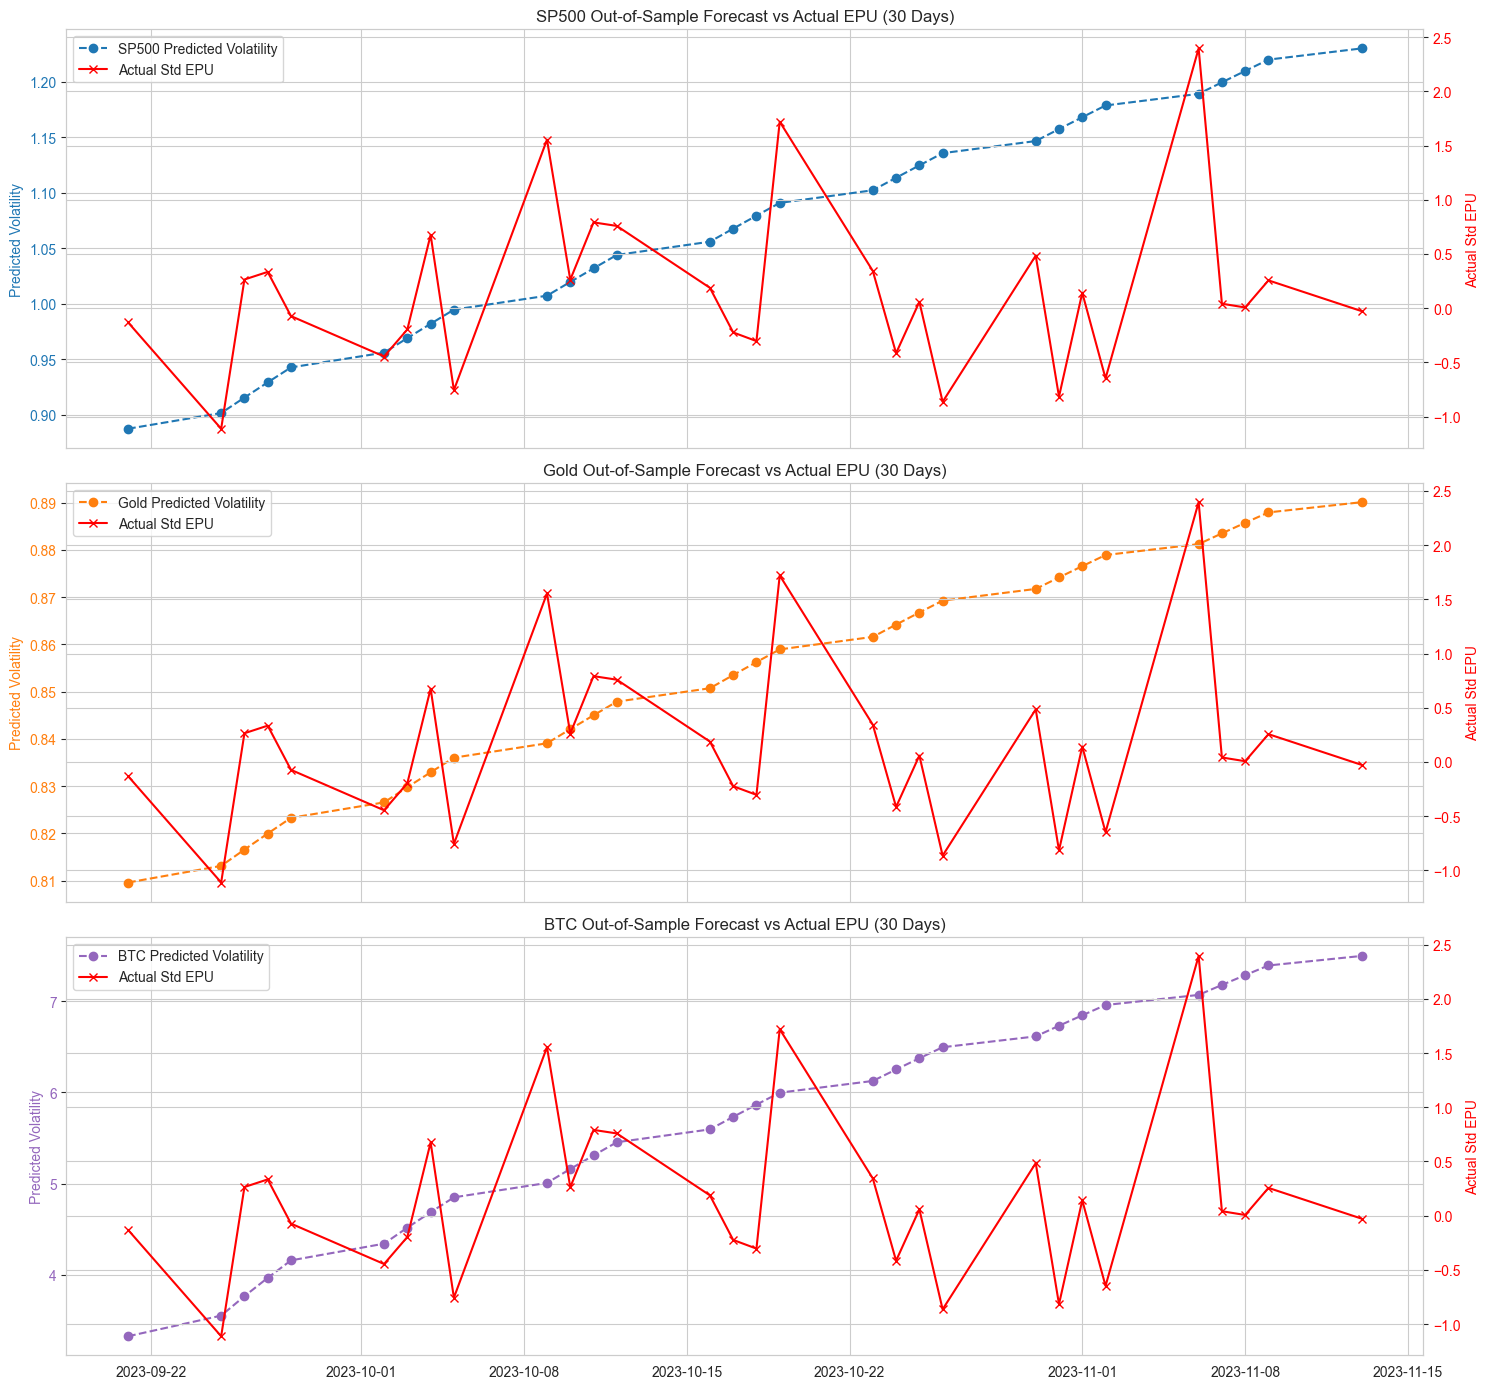

In [19]:
# Define hold-out period
hold_out_days = 30
train_df = df.iloc[:-hold_out_days]
test_df = df.iloc[-hold_out_days:]

print(f"--- Out-of-Sample Evaluation (Hold-out: {hold_out_days} days) ---")
print(f"Training Period: {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"Testing Period: {test_df.index[0].date()} to {test_df.index[-1].date()}\n")

out_of_sample_vols = pd.DataFrame(index=test_df.index)

# Refit models on training data and forecast
for asset in assets:
    # 1. Fit on train
    model_train = arch_model(
        y=train_df[f'{asset}_LogRet'],
        mean='Constant',
        vol='Garch',
        p=1, q=1,
        dist='studentst'
    )
    res_train = model_train.fit(disp='off')
    
    # 2. Forecast hold-out period
    forecasts_out = res_train.forecast(horizon=hold_out_days)
    
    # Extract the forecasted variance for the horizon from the last training observation
    pred_var_out = forecasts_out.variance.iloc[-1].values
    pred_vol_out = np.sqrt(pred_var_out)
    
    out_of_sample_vols[f'{asset}_Forecast_Vol'] = pred_vol_out

# 3. Plot Forecasts vs Actual EPU
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

for i, asset in enumerate(assets):
    ax1 = axes[i]
    color = 'tab:blue' if asset == 'SP500' else ('tab:orange' if asset == 'Gold' else 'tab:purple')
    
    # Plot Predicted Volatility
    ax1.plot(test_df.index, out_of_sample_vols[f'{asset}_Forecast_Vol'], color=color, marker='o', linestyle='dashed', label=f'{asset} Predicted Volatility')
    ax1.set_ylabel('Predicted Volatility', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_title(f'{asset} Out-of-Sample Forecast vs Actual EPU ({hold_out_days} Days)')
    
    # Plot ACTUAL EPU from the hold-out set
    ax2 = ax1.twinx()
    ax2.plot(test_df.index, test_df['EPU_Std'], color='red', marker='x', label='Actual Std EPU')
    ax2.set_ylabel('Actual Std EPU', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()
